<a href="https://colab.research.google.com/github/g2450001/Packaging-Color-and-Customer-Lifetime-Value-CLV-Analysis-in-the-Japanese-Cosmetic-Industry/blob/main/Estimated_CLV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/cosme_translated_with_rgb.csv')

df.head()


,Title_EN,Category_EN,Description_EN,Best cosme_EN,Ranking_EN,Description3_EN,Review_EN,Brand_EN,Image_RGB,Rating,points
0,Tone Up Lifting Balm,[Serum],"Price including tax: 22g, 13,200 yen |",NaN,NaN,release date:-,12 reviews,CIRMAGE,"(np.int64(206), np.int64(204), np.int64(206))",1.0,0.0pt
1,Raw VC whitening liquid,"[Booster, introduction liquid, serum]","Price including tax: 1ml x 28 packets, 3,960 y...",Best Cosmetics,Ranking IN,Release date: 2021/11/1,"1,533 reviews",Yunth,"(np.int64(250), np.int64(232), np.int64(231))",4.7,68.6pt
2,Liposome Advanced Repair Serum,"[Booster, introduction liquid, serum]","Price including tax: 30ml, 8,250 yen / 50ml, 1...",Best Cosmetics,Ranking IN,Release date: 2021/9/16,"14,326 reviews",Cosme decollet,"(np.int64(212), np.int64(206), np.int64(216))",5.8,910.4pt
3,Moisturizing skin care base,"[All-in-one cosmetics, sunscreen, UV care (for...","Price including tax: 30g, 1,430 yen |",NaN,Ranking IN,Release date: 2021/11/15,"1,443 reviews",Dry,"(np.int64(251), np.int64(251), np.int64(251))",5.3,174.7pt
4,Takami Skin Peel,"[Booster, Injection Liquid, Gommage, Peeling]","Price including tax: 10ml, 1,000 yen / 30ml, 5...",Best Cosmetics,Ranking IN,Release date: 2005/8/19,"14,580 reviews",Takami,"(np.int64(220), np.int64(224), np.int64(240))",5.3,429.1pt


In [ ]:

df['Price'] = df['Description_EN'].str.extract(r'(\d+(?:,\d{3})*)\s?yen')[0]
df['Price'] = df['Price'].replace({',': ''}, regex=True).astype(float)


df['Review_Count'] = df['Review_EN'].str.extract(r'(\d+)\s?reviews')[0]
df['Review_Count'] = df['Review_Count'].astype(float)


df['Price'] = df['Price'].fillna(0)
df['Review_Count'] = df['Review_Count'].fillna(0)


df = df[df['Price'] > 0]


print(df[['Title_EN', 'Price', 'Review_Count']])




                                       Title_EN    Price  Review_Count
0                          Tone Up Lifting Balm  13200.0          12.0
1                       Raw VC whitening liquid   3960.0         533.0
2                Liposome Advanced Repair Serum   8250.0         326.0
3                   Moisturizing skin care base   1430.0         443.0
4                              Takami Skin Peel   1000.0         580.0
...                                         ...      ...           ...
5995                    Tea Tree Essential Mask    220.0          29.0
5996  CICIBELLA Sheet Mask VC100 x CBD 7 sheets    715.0          31.0
5997     Skin Longjevity Phyto C UV Moisturizer   7150.0          11.0
5998                  Overnight Brightening Gel   3190.0          26.0
5999              Sinal Exia White Medical Milk   4950.0          36.0

[5168 rows x 3 columns]


In [ ]:
import re

def extract_rgb_tuple(rgb_string):

    if isinstance(rgb_string, str):

        rgb_values = re.findall(r'\d+', rgb_string)
        return tuple(map(int, rgb_values))
    elif pd.isnull(rgb_string):
        return np.nan
    else:
        try:
            rgb_values = re.findall(r'\d+', rgb_string)
            return tuple(map(int, rgb_values))
        except (TypeError, ValueError):
            return np.nan

df['Image_RGB'] = df['Image_RGB'].apply(extract_rgb_tuple)


print(df.head())

                         Title_EN  \
0            Tone Up Lifting Balm   
1         Raw VC whitening liquid   
2  Liposome Advanced Repair Serum   
3     Moisturizing skin care base   
4                Takami Skin Peel   

                                         Category_EN  \
0                                            [Serum]   
1              [Booster, introduction liquid, serum]   
2              [Booster, introduction liquid, serum]   
3  [All-in-one cosmetics, sunscreen, UV care (for...   
4      [Booster, Injection Liquid, Gommage, Peeling]   

                                      Description_EN   Best cosme_EN  \
0             Price including tax: 22g, 13,200 yen |             NaN   
1  Price including tax: 1ml x 28 packets, 3,960 y...  Best Cosmetics   
2  Price including tax: 30ml, 8,250 yen / 50ml, 1...  Best Cosmetics   
3              Price including tax: 30g, 1,430 yen |             NaN   
4  Price including tax: 10ml, 1,000 yen / 30ml, 5...  Best Cosmetics   

   Rank

In [ ]:
max_review_count = df['Review_Count'].max()
df['Normalized_Review_Count'] = df['Review_Count'] / max_review_count


max_rating = df['Rating'].max()
df['Normalized_Rating'] = df['Rating'] / max_rating

df['Estimated_CLV_Proxy'] = df['Price'] * df['Normalized_Review_Count'] * df['Normalized_Rating']

print(df[['Title_EN', 'Price', 'Review_Count', 'Normalized_Review_Count', 'Rating', 'Normalized_Rating', 'Estimated_CLV_Proxy']])

                                       Title_EN    Price  Review_Count  \
0                          Tone Up Lifting Balm  13200.0          12.0   
1                       Raw VC whitening liquid   3960.0         533.0   
2                Liposome Advanced Repair Serum   8250.0         326.0   
3                   Moisturizing skin care base   1430.0         443.0   
4                              Takami Skin Peel   1000.0         580.0   
...                                         ...      ...           ...   
5995                    Tea Tree Essential Mask    220.0          29.0   
5996  CICIBELLA Sheet Mask VC100 x CBD 7 sheets    715.0          31.0   
5997     Skin Longjevity Phyto C UV Moisturizer   7150.0          11.0   
5998                  Overnight Brightening Gel   3190.0          26.0   
5999              Sinal Exia White Medical Milk   4950.0          36.0   

      Normalized_Review_Count  Rating  Normalized_Rating  Estimated_CLV_Proxy  
0                    0.000610  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re





In [ ]:
def extract_rgb_tuple(rgb_string):
    rgb_string = str(rgb_string)
    rgb_values = re.findall(r'\d+', rgb_string)

    while len(rgb_values) < 3:
        rgb_values.append('0')

    return tuple(map(int, rgb_values))


df['Image_RGB'] = df['Image_RGB'].apply(extract_rgb_tuple)


df['RGB_R'] = df['Image_RGB'].apply(lambda x: x[0])
df['RGB_G'] = df['Image_RGB'].apply(lambda x: x[1])
df['RGB_B'] = df['Image_RGB'].apply(lambda x: x[2])

In [ ]:
df = df.dropna(subset=['Estimated_CLV_Proxy', 'RGB_R', 'RGB_G', 'RGB_B'])

X = df[['RGB_R', 'RGB_G', 'RGB_B']]
y = df['Estimated_CLV_Proxy']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Absolute Error: 55.72862281791708
Mean Squared Error: 25234.096598831675
R-squared: -0.0025829225918969634


Model Interpretation

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [0.37851287 0.80014578 0.37851287]
Intercept: 43.525055110140926


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)


y_pred_rf = rf_model.predict(X_test_scaled)
print(f"Random Forest R-squared: {r2_score(y_test, y_pred_rf)}")

Random Forest R-squared: -0.014806833352524862


In [ ]:
!pip install seaborn matplotlib

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

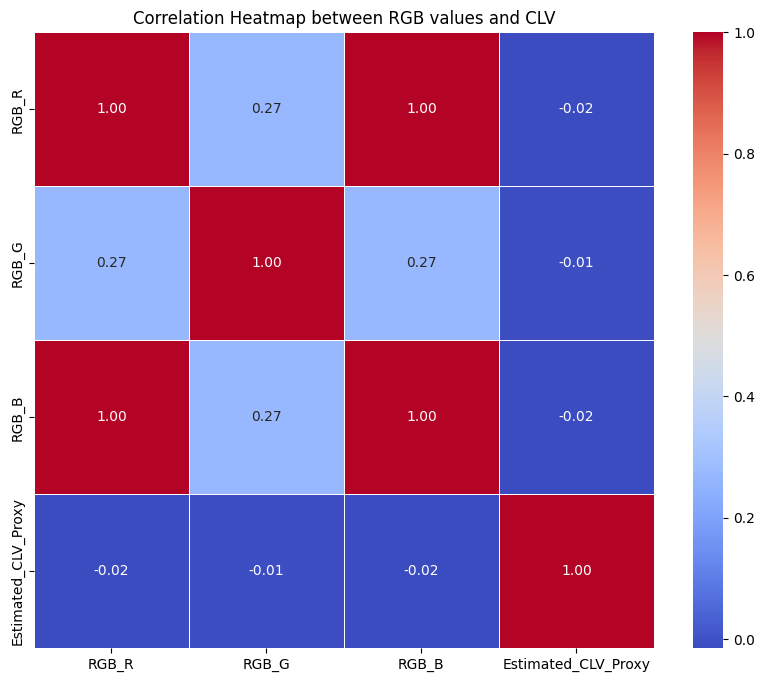

In [ ]:
df = df.dropna(subset=['Estimated_CLV_Proxy', 'RGB_R', 'RGB_G', 'RGB_B'])

correlation_matrix = df[['RGB_R', 'RGB_G', 'RGB_B', 'Estimated_CLV_Proxy']].corr()


plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap between RGB values and CLV')
plt.show()